<a href="https://colab.research.google.com/github/clarkti5/introduction-to-statistics/blob/main/2_1_Examining_numerical_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examining numerical data

---

#### Summary videos

- [Summarizing and graphing numerical data](https://youtu.be/Xm0PPtci3JE?si=Uh_0uUPDQGAND18G) (3 minutes)

#### Walkthrough videos

- [Scatterplots and dot plots](https://drive.google.com/file/d/1aUlh8iYuuQBIqnCn8cqQCOsWrQrKR-6A/view?usp=sharing) (9 minutes)
- [Histograms and shape](https://drive.google.com/file/d/1OpZIDyBVSq7PvWCkyTfwWvlMwoaR6N_J/view?usp=sharing) (12 minutes)
- [Variance and standard deviation](https://drive.google.com/file/d/1aTTcxMy5uSGbKCaAFkpr2x4ehLLMVim6/view?usp=sharing) (14 minutes)
- [Box plots, quartiles, and the median](https://drive.google.com/file/d/1fTOv40DkVLfKcR4f2azTVsCxRYH3QgsH/view?usp=sharing) (15 minutes)

---

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from plotnine import *

Let's import the `loan50` data set, which contains information on 50 randomly selected loans offered through a peer-to-peer lending company called Lending Club.

In [ ]:
loan50 = pd.read_csv('https://raw.githubusercontent.com/clarkti5/math-209-data-sets/main/loan50.csv')

The first five rows of this data set are displayed below. Note that each row represents a single loan.

In [ ]:
loan50.head()

## Scatterplots for paired data

A **scatterplot** provides a case-by-case view of data for two numerical variables.

Consider `total_income` and `loan_amount` from the `loan50` data set.

In [ ]:
(
    ggplot(loan50) +
    aes(x = 'total_income', y = 'loan_amount') +
    geom_point() +
    geom_smooth(method = 'lm', se = False)
)

### Questions

What can you conclude about these variables from this scatterplot?

* Does this plot suggest that the variables are associated? Why or why not?
* Would you call the association weak or strong?
* Would you call the association positive or negative?
* Would you call the association linear or nonlinear?


## Dot plots and the mean
A **dot plot** is a one-variable version of a scatterplot. Let's consider the (stacked) dot plot of the `interest_rate` variable from page 43 of the textbook.

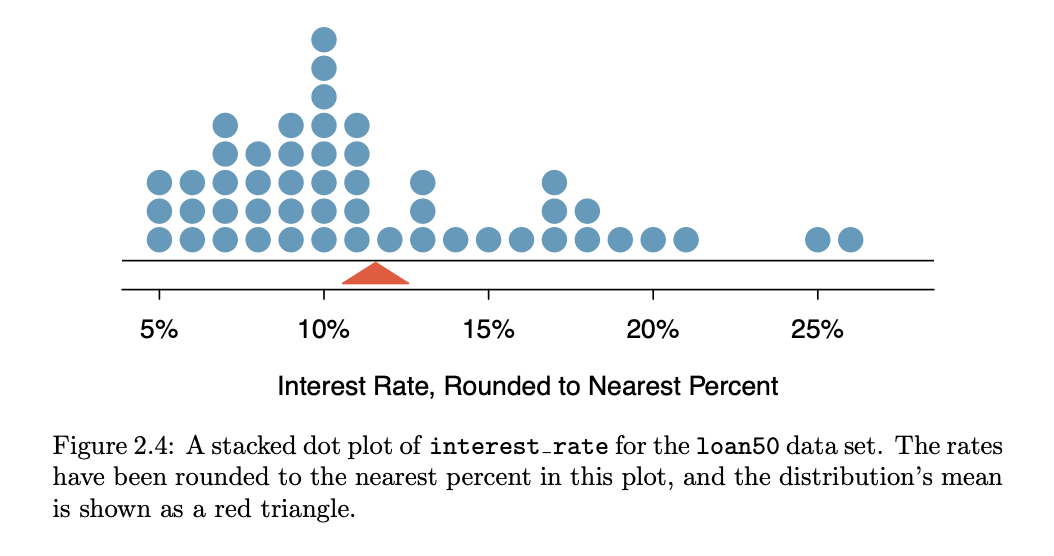

The **mean** (sometimes called **average**) is a common way to measure the **center** of a **distribution** of data.

### Mean

The **sample mean** is computed as the sum of the observed values divided by the number of observations as in
$$\bar{x} = \dfrac{x_1 + x_2 + \cdots + x_n}{n},$$
where the $x_i$ are the observed values and $n$ is the number of observed values.

The **population mean** is computed the same way, but would include *all* data values, not just the values from the sample. The population mean is typically denoted $\mu$.


### Exercise

- For the `interest_rate` variable from `loan50`, what would $n$ be?
- What is the mean value for `interest_rate`?

In [ ]:
loan50['interest_rate'].mean()

## Histograms and shape

While dot plots can be useful for small data sets, for larger data sets it is often preferable to collect data into *bins*. These binned counts are often plotted as bars in a **histogram**.

Consider a histogram of the `interest_rate` variable. The vertical axis measures the **frequency** (or **count**) of observed values falling within a bin.

In [ ]:
(
  ggplot(loan50) +
  aes(x = 'interest_rate') +
  geom_histogram(binwidth = 5, color = 'black', fill = None)
)

### Question

- How would you *describe* this histogram?
- What sort of interesting features do you notice?

### Long tails to identify skew
When data trails off in one direction, the distribution is said to have a **long tail**.
*   If the distribution has a long left tail, it is called **left skewed**.
*   If the distribution has a long right tail, it is called **right skewed**.
*   If the data trails off roughly equally in both directions, it is called **symmetric**.



### Exercise

Identify whether the following histograms are left skewed, right skewed, or symmetric.

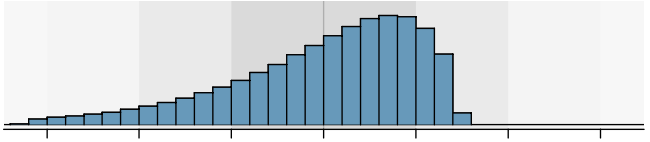

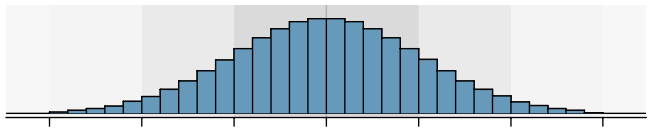

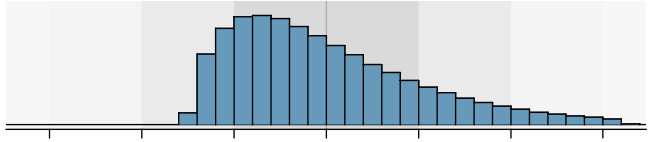

### Modes
A **mode** is represented by a *prominent peak* in the distribution on a histogram. Note that, in this class, there may be one, none, or many modes!

A distribution with exactly one mode is **unimodal**, a distribution with two modes is **bimodal**, and a distribution with more than two modes is **multimodal**. A distribution with no mode is called **uniform**.

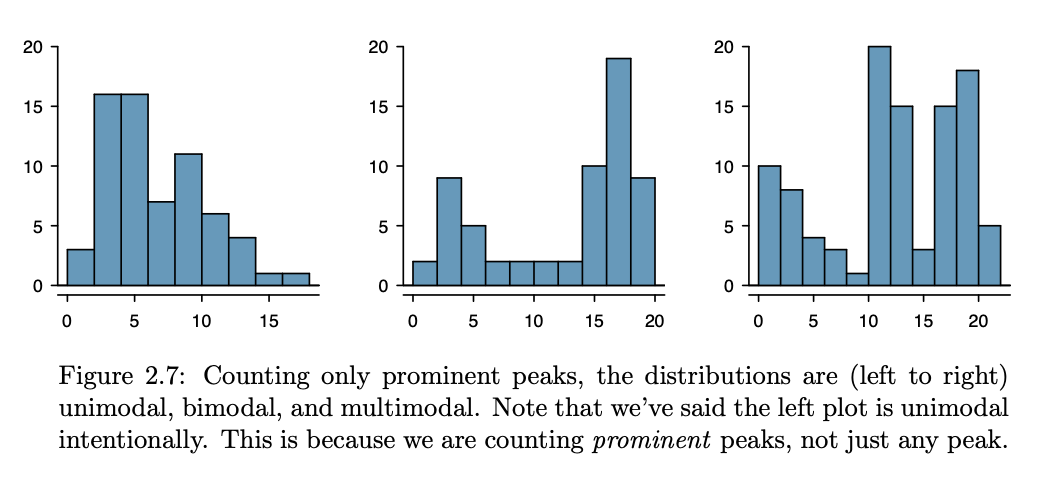

### Describing a histogram

When **describing a histogram**, we want to be sure to address the

- center (as measured by *mean*, *median*, or *mode*)
- shape (*left skewed*, *right-skewed*, or *symmetric*), and
- spread (as measured by *standard deviation* or *IQR*).

## Variance and standard deviation

The mean was introduced as a measure for the *center* of a data set. Modes can also be thought of as measures of *center*. Skewness tells us about the *shape* of the data.

Another important feature is the *variability* or *spread* in the data, measured by concepts called **deviation**, **variance**, and **standard deviation**.

### Deviation
The **deviation** is the difference between an observed value and the mean value, computed as
$$x_i - \bar{x}.$$

In [ ]:
x_bar = loan50['interest_rate'].mean()

interest_rate_deviation = loan50['interest_rate'] - x_bar

interest_rate_deviation.values

### Variance
Squaring the deviations and then taking the average (out of $n - 1$), yields the **variance** of the data set.

$$ s^2 = \dfrac{\Sigma_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}. $$

In [ ]:
interest_rate_deviation_squared = interest_rate_deviation * interest_rate_deviation

interest_rate_deviation_squared.values

In [ ]:
interest_rate_variance = interest_rate_deviation_squared.sum() / (50 - 1)

interest_rate_variance

### Standard deviation

The **standard deviation** is the square root of the variance. It represents the typical deviation (or *spread*) of observations from the mean.

The sample standard deviation is often denoted $s$, while the population standard deviation is denoted $\sigma$.

The standard deviation is computable by hand, of course, but that is extremely tedious! We can use the following command to compute the standard deviation of `interest_rate` for us.

In [ ]:
loan50['interest_rate'].std()

### An empirical rule

*   About 70% of data are within 1 standard deviation from the mean.
*   About 95% of data are within 2 standard deviations from the mean.


### Exercise

Investigate the Empirical Rule on the histogram for `interest_rate` above.


### Example

Compute the mean, variance, and standard deviation of the following 5 numbers.

$$ 2, 4, 6, 8, 10 $$

In [ ]:
# mean

(2 + 4 + 6 + 8 + 10)/5

6.0

In [ ]:
# variance

((2 - 6)**2 + (4 - 6)**2 + (6 - 6)**2 + (8 - 6)**2 + (10 - 6)**2)/(5 - 1)

In [ ]:
# standard deviation

import math

math.sqrt(10)

## Box plots, quartiles, and the median

A **box plot** summarizes data using 5 statistics (sometimes called the 5 number summary) as well as indicating unusual values.

The 5 statistics visualized are the *minimum*, *first quartile*, *median*, *thrid quartile*, and the *maximum*.


In [ ]:
(
  ggplot(loan50) +
  aes(y = 'interest_rate') +
  geom_boxplot() +
  xlim(-1, 1)
)

Consider, also, this image from page 49 of the textbook.

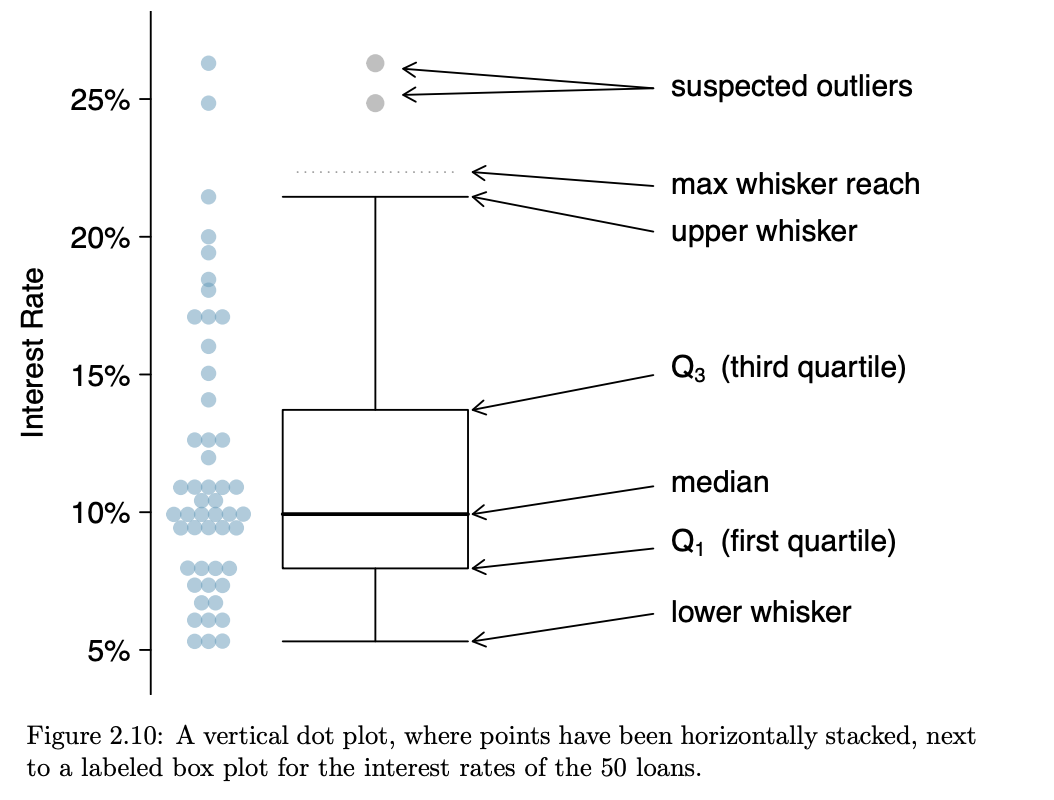



*   If the data are recorded from smallest to largest, the **median** is the number in the middle (or the average of the two middle observations). It represents the *50th percentile*.
*   The **first quartile** ($Q_1$) represents the *25th percentile*. It is the median of the lower 50% of the data.
*   The **third quartile** ($Q_3$) represents the *75th percentile*. It is the median of the upper 50% of the data.
*   The **interquartile range** ($IQR$) is the difference of the third and first quartiles and captures the middle 50% of the data.
*   The **lower whisker** is at the lowest data point above $Q_1 - 1.5 \cdot IQR$.
*   The **upper whisker** is at the highest data point below $Q_3 + 1.5 \cdot IQR$.
*   The **range** of the data is the difference between its maximum and minimum values.
*   Observations lying beyond the whiskers are potentially **outliers**.



### Exercise

Estimate the values for $Q_1$, $Q_3$, the median, the $IQR$, whiskers, and range for `interest_rate` from the box plot(s) above.

In [ ]:
Q_1 = loan50['interest_rate'].quantile(q = 0.25)

print(Q_1)

In [ ]:
median = loan50['interest_rate'].quantile(q = 0.50)

print(median)

In [ ]:
Q_3 = loan50['interest_rate'].quantile(q = 0.75)

print(Q_3)

In [ ]:
IQR = Q_3 - Q_1

print(IQR)

In [ ]:
min_whisker_reach = Q_1 - 1.5 * IQR

print(min_whisker_reach)

In [ ]:
minimum_value = loan50['interest_rate'].min()

print(minimum_value)

In [ ]:
max_whisker_reach = Q_3 + 1.5 * IQR

print(max_whisker_reach)

In [ ]:
maximum_value = loan50['interest_rate'].max()

print(maximum_value)

In [ ]:
range = maximum_value - minimum_value

print(range)

Much of this information can also be computed using `.describe()`.

In [ ]:
loan50['interest_rate'].describe()

### Example

Find the median and IQR for the following 5 numbers.

$$ 2, 4, 6, 8, 10$$

In [ ]:
# median

6

In [ ]:
# Q1

(2 + 4)/2

In [ ]:
# Q3

(8 + 10)/2

In [ ]:
# IQR

9 - 3

## Robust statistics

To say a statistic is **robust** means that introducing new observations are not likely to alter the statistic much. Consider the following from page 51 of the textbook.

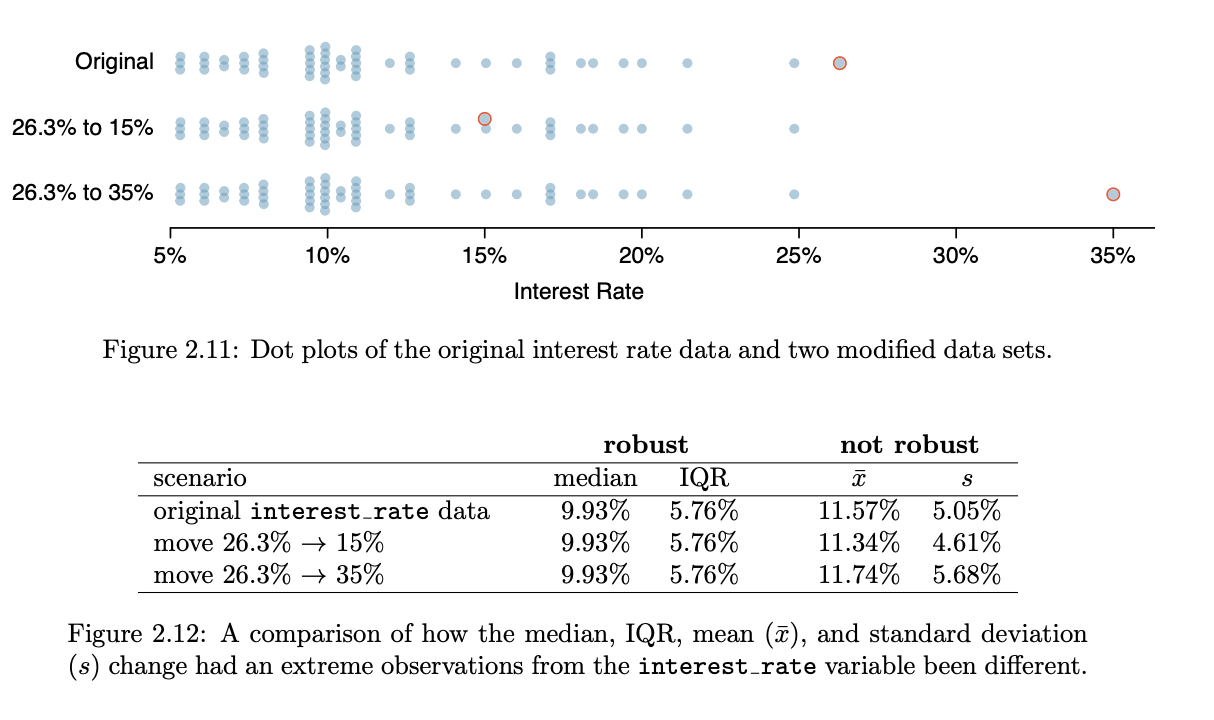

Median and IQR are *robust* measures of center and spread (respectively), compared to mean and standard deviation.

## The importance of visualization
For an interesting look at the importance of visualizing your data, see

https://www.research.autodesk.com/publications/same-stats-different-graphs/.

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.

## Bonus content!

### Transforming data


For strongly skewed data, it is sometimes useful to **transform** the data, which means using a function to rescale the data.

Consider the example provided on page 52 of the textbook.
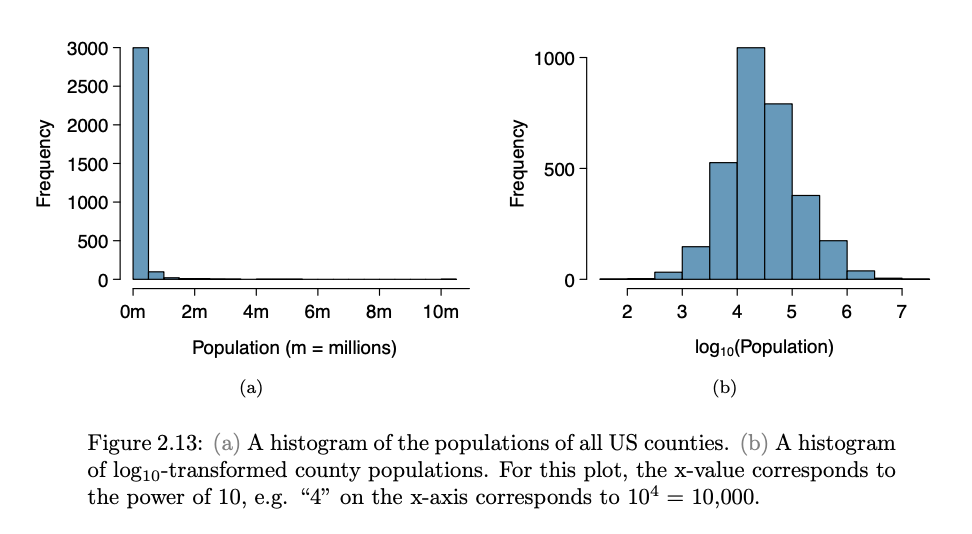

The above example uses the base 10 logarithm ($\log_{10}$) to rescale the $x$-axis, resulting in a histogram that is easier to study. Other commmon transformations include the square root function ($\sqrt{x}$) and the reciprocal function ($1/x$).

### Mapping data

Data involving geographic elements are often useful to visualize using an **intensity map** (sometimes called a **heat map**).

Consider the following from page 55 of the textbook.
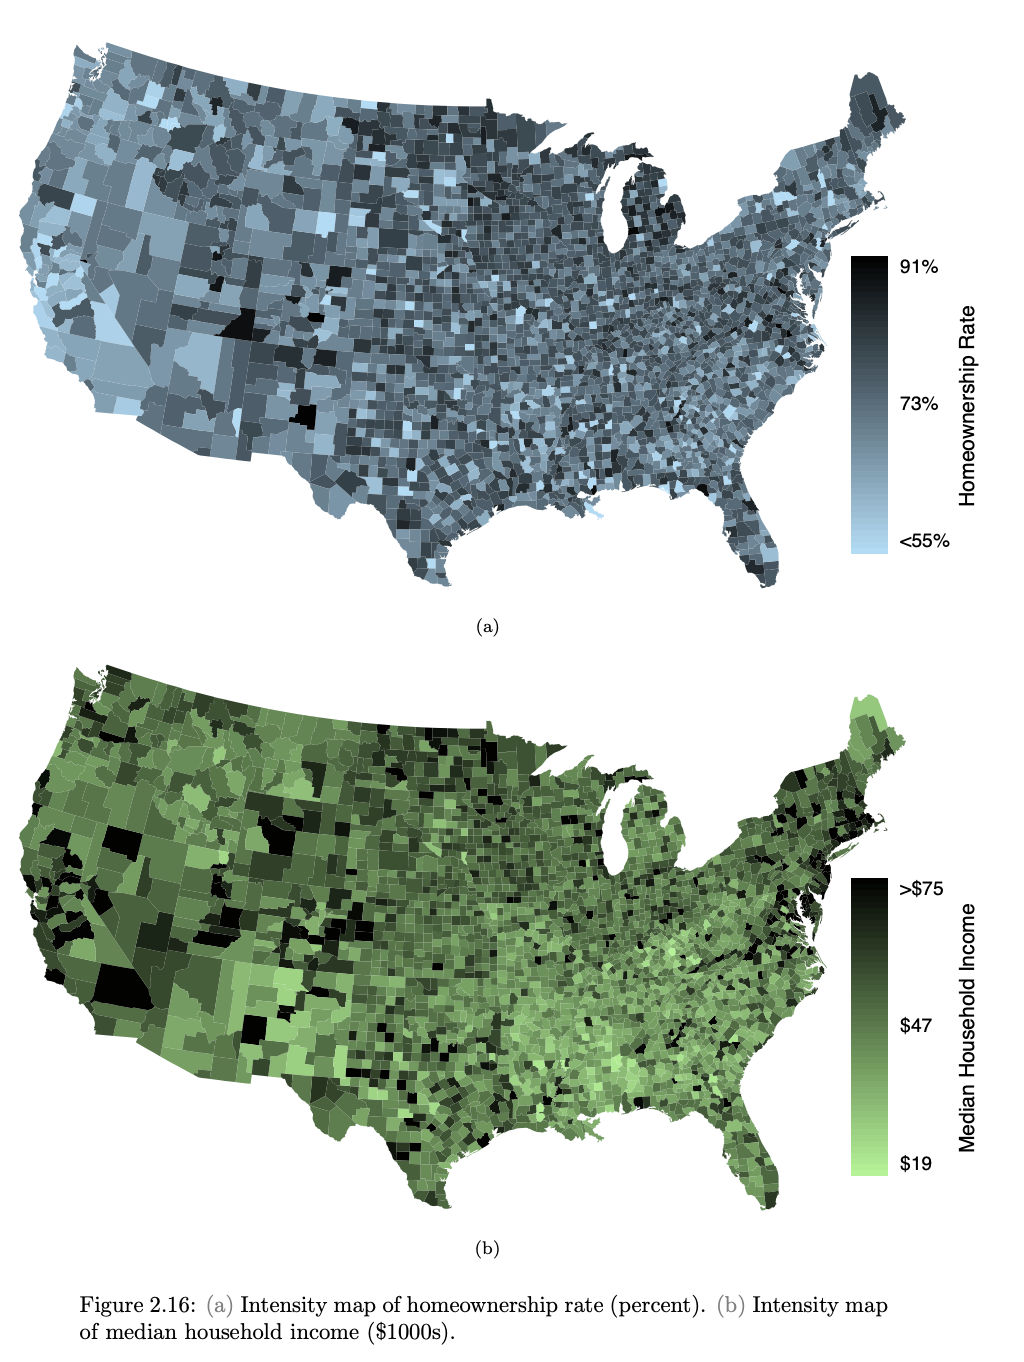